Make sure 'Fake.csv' and 'True.csv' are in the current directory.
Unzipped and loaded Fake.csv from Fake.csv.zip
Unzipped and loaded True.csv from True.csv.zip
Fake news records: 23481
True news records: 21417
Combined dataset shape: (44898, 5)
First 5 rows of the combined and shuffled dataset:
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotl

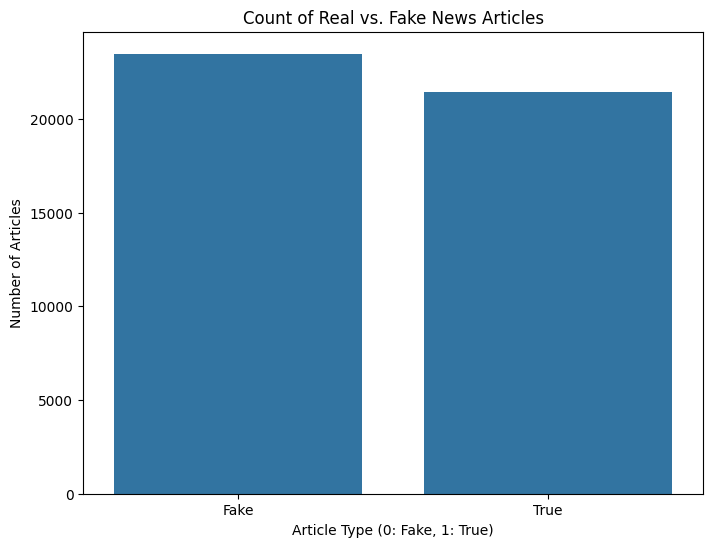

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the two CSV files
try:
    fake_news = pd.read_csv('Fake.csv')
    true_news = pd.read_csv('True.csv')
    print("Successfully loaded Fake.csv and True.csv")
except FileNotFoundError:
    print("Make sure 'Fake.csv' and 'True.csv' are in the current directory.")
    # Attempt to unzip if the files are zipped
    import zipfile
    import os

    if os.path.exists('Fake.csv.zip'):
        with zipfile.ZipFile('Fake.csv.zip', 'r') as zip_ref:
            zip_ref.extractall('.')
        fake_news = pd.read_csv('Fake.csv')
        print("Unzipped and loaded Fake.csv from Fake.csv.zip")

    if os.path.exists('True.csv.zip'):
        with zipfile.ZipFile('True.csv.zip', 'r') as zip_ref:
            zip_ref.extractall('.')
        true_news = pd.read_csv('True.csv')
        print("Unzipped and loaded True.csv from True.csv.zip")


# 2. Add a new column called 'label' to both datasets
fake_news['label'] = 0  # 0 for Fake
true_news['label'] = 1  # 1 for True

print(f"Fake news records: {len(fake_news)}")
print(f"True news records: {len(true_news)}")

# 3. Combine them into one single DataFrame
combined_df = pd.concat([fake_news, true_news], ignore_index=True)

# 4. Shuffle the combined dataset
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Combined dataset shape: {combined_df.shape}")
print("First 5 rows of the combined and shuffled dataset:")
print(combined_df.head())

# 5. Create a simple bar chart showing the count of Real vs. Fake articles
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=combined_df)
plt.title('Count of Real vs. Fake News Articles')
plt.xlabel('Article Type (0: Fake, 1: True)')
plt.ylabel('Number of Articles')
plt.xticks(ticks=[0, 1], labels=['Fake', 'True'])
plt.show()

In [2]:
import re

def clean_text_publisher_tag(text):
    """
    Removes publisher tags like 'WASHINGTON (Reuters) - ' from the start of the text.
    It looks for patterns ending with ') - ' or similar and removes everything up to and including the first hyphen.
    """
    # Pattern to match a city/organization followed by (Publisher) -
    # and also a general pattern like (Publisher) -
    match = re.match(r'^(?:[A-Z\s]+(?:\([A-Za-z]+\))? - |\([A-Za-z]+\) - )', text)
    if match:
        # Find the first hyphen and remove everything before it, including the hyphen
        first_hyphen_index = text.find('-')
        if first_hyphen_index != -1:
            return text[first_hyphen_index + 1:].strip()
    return text


# Apply the cleaning function to the 'text' column
combined_df['text'] = combined_df['text'].apply(clean_text_publisher_tag)

print("First 5 rows of the combined and shuffled dataset after text cleaning:")
print(combined_df.head())

First 5 rows of the combined and shuffled dataset after text cleaning:
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  U.S. President Donald Trump removed his chief ...  politicsNews   
2  Puerto Rico Governor Ricardo Rossello said on ...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       Jun

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Define 'text' column as X and 'label' column as y
X = combined_df['text']
y = combined_df['label']

# 2. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# 3. Initialize a TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# 4. Use fit_transform on the X_train data, and transform on the X_test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 5. Print the shape of the new vectorized X_train and X_test matrices
print(f"Shape of vectorized X_train: {X_train_tfidf.shape}")
print(f"Shape of vectorized X_test: {X_test_tfidf.shape}")

Shape of X_train: (35918,)
Shape of X_test: (8980,)
Shape of y_train: (35918,)
Shape of y_test: (8980,)
Shape of vectorized X_train: (35918, 5000)
Shape of vectorized X_test: (8980, 5000)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for smaller datasets or when L1/L2 penalties are needed

# 2. Train (fit) the model using the vectorized X_train and y_train data
log_reg_model.fit(X_train_tfidf, y_train)

# 3. Make predictions on the vectorized X_test data
y_pred = log_reg_model.predict(X_test_tfidf)

# 4. Print the accuracy score and a full classification report
print("Logistic Regression Model Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Model Performance:
Accuracy Score: 0.9766

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      4710
           1       0.97      0.98      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



In [5]:
import joblib

# Save the Logistic Regression model
joblib.dump(log_reg_model, 'fake_news_model.pkl')
print("Logistic Regression model saved as 'fake_news_model.pkl'")

# Save the TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
print("TF-IDF Vectorizer saved as 'tfidf_vectorizer.pkl'")

Logistic Regression model saved as 'fake_news_model.pkl'
TF-IDF Vectorizer saved as 'tfidf_vectorizer.pkl'
